In [24]:

%load_ext autoreload
%autoreload 2

import sys

file_path = '/Users/michaelfinch/CA1-interneuron-GLM' #Mac
#file_path=r"C:\Users\Msfin\cloned_repositories\CA1-interneuron-GLM"

sys.path.append(file_path)

from utils_TCA_clustering_scratchpad import *
from GLM_regression_plotting import *


from modelling_to_date_utils import *

from selectivity_over_learning_utils import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [25]:
# activity_dict, predicted_activity_dict_NDNF_new, filtered_factors_dict, new_NDNF_activity_dict, new_NDNF_velocity_dict, residual_activity_dict_NDNF_new = load_data_regular(file_path=file_path, name="NDNFanalC", new_NDNF=True)
# GLM_params, activity_dict, double_predicted_activity_dict_NDNF_new, factors_dict, filtered_factors_dict, residual_activity_dict_NDNF_new = load_data_regular(file_path=file_path, name="NDNFanalC", new_NDNF=True)
# GLM_params_old_NDNF, activity_dict_old_NDNF, double_predicted_activity_dict_NDNF_old, factors_dict_old_NDNF, filtered_factors_dict_old_NDNF, residual_activity_dict_NDNF_old = load_data_regular(file_path=file_path, name="NDNFindivsomata_GLM", new_NDNF=False)
GLM_params_SST, activity_dict_SST, double_predicted_activity_dict_SST, factors_dict_SST, filtered_factors_dict_SST, residual_activity_dict_SST = load_data_regular(file_path=file_path, name="SSTindivsomata_GLM", new_NDNF=False)
GLM_params_EC, activity_dict_EC, double_predicted_activity_dict_EC, factors_dict_EC, filtered_factors_dict_EC, residual_activity_dict_EC = load_data_regular(file_path=file_path, name="EC_GLM", new_NDNF=False)
GLM_params_NDNF_newest, activity_dict_NDNF_newest, double_predicted_activity_dict_NDNF_newest, factors_dict_NDNF_newest, filtered_factors_dict_NDNF_newest, residual_activity_dict_NDNF_newest = load_data_regular(file_path=file_path, name="NDNF_E1A1B", new_NDNF=True)

fixed_factors_dict_NDNF_newest = subset_factors(factors_dict_NDNF_newest)
fixed_residual_activity_dict_NDNF_newest = subset_factors(residual_activity_dict_NDNF_newest)
fixed_activity_dict_NDNF_newest = subset_factors(activity_dict_NDNF_newest)



In [26]:

mse_dir = "/Users/michaelfinch/CA1-interneuron-GLM/datasets/cell_SST_model_ranks20_contig_x00_cells"
cell_SST_model_ranks20_contig_x00 = get_model_data_per_cell(mse_dir)

mse_dir = "/Users/michaelfinch/CA1-interneuron-GLM/datasets/cell_EC_model_ranks20_contig_x00_cells"
cell_EC_model_ranks20_contig_x00 = get_model_data_per_cell(mse_dir)

mse_dir = "/Users/michaelfinch/CA1-interneuron-GLM/datasets/real_final_NDNF_model_ranks20_contig_x00_cell"
cell_NDNF_model_ranks20_contig_x00 = get_model_data_per_cell(mse_dir)

def get_cp_dict(cell_SST_model_ranks20_contig_x00):
    changepoints_dict = {}
    for animal in cell_SST_model_ranks20_contig_x00[20]:
        changepoints_cell_dict = {}
        for cell in cell_SST_model_ranks20_contig_x00[20][animal]:
            labels = cell_SST_model_ranks20_contig_x00[20][animal][cell][1][f'cell_{cell}']["labels_dict"]["clusters_chosen_3"]
            changepoints = np.where(np.diff(labels) != 0)[0]
            changepoints_cell_dict[cell] = changepoints
        changepoints_dict[animal] = changepoints_cell_dict

    return changepoints_dict



fixed_model_dict_NDNF_newest = get_fixed_model_dict_NDNF_newest(cell_NDNF_model_ranks20_contig_x00)

cp_dict_EC = get_cp_dict(cell_EC_model_ranks20_contig_x00)
cp_dict_NDNF = get_cp_dict(fixed_model_dict_NDNF_newest)
cp_dict_SST = get_cp_dict(cell_SST_model_ranks20_contig_x00)

Loaded MSEs for 1 rank(s).
  Rank 20:
    Animal 0: 5 cells
    Animal 1: 15 cells
    Animal 2: 6 cells
    Animal 3: 4 cells
    Animal 4: 13 cells
    Animal 5: 13 cells
    Animal 6: 3 cells
    Animal 7: 3 cells
    Animal 8: 3 cells
    Animal 9: 10 cells
Loaded MSEs for 1 rank(s).
  Rank 20:
    Animal 0: 192 cells
    Animal 1: 150 cells
    Animal 2: 154 cells
    Animal 3: 82 cells
    Animal 4: 74 cells
    Animal 5: 64 cells
    Animal 6: 76 cells
Loaded MSEs for 1 rank(s).
  Rank 20:
    Animal 0: 12 cells
    Animal 1: 16 cells
    Animal 2: 4 cells
    Animal 3: 10 cells
    Animal 4: 8 cells
    Animal 5: 7 cells
    Animal 6: 11 cells
    Animal 7: 10 cells
    Animal 8: 17 cells
    Animal 9: 17 cells
    Animal 10: 9 cells
    Animal 11: 6 cells
    Animal 12: 10 cells
    Animal 13: 9 cells
    Animal 14: 6 cells
    Animal 15: 12 cells
    Animal 16: 7 cells
    Animal 17: 7 cells
    Animal 18: 7 cells
    Animal 19: 10 cells
    Animal 20: 9 cells
    Animal 21: 

In [27]:
def get_cp_dict(cell_SST_model_ranks20_contig_x00):
    changepoints_dict = {}
    for animal in cell_SST_model_ranks20_contig_x00[20]:
        changepoints_cell_dict = {}
        for cell in cell_SST_model_ranks20_contig_x00[20][animal]:
            labels = cell_SST_model_ranks20_contig_x00[20][animal][cell][1][f'cell_{cell}']["labels_dict"]["clusters_chosen_3"]
            changepoints = np.where(np.diff(labels) != 0)[0]
            changepoints_cell_dict[cell] = changepoints
        changepoints_dict[animal] = changepoints_cell_dict

    return changepoints_dict



fixed_model_dict_NDNF_newest = get_fixed_model_dict_NDNF_newest(cell_NDNF_model_ranks20_contig_x00)

cp_dict_EC = get_cp_dict(cell_EC_model_ranks20_contig_x00)
cp_dict_NDNF = get_cp_dict(fixed_model_dict_NDNF_newest)
cp_dict_SST = get_cp_dict(cell_SST_model_ranks20_contig_x00)

In [28]:
def get_activity_early(activity_dict_SST, cp_dict_SST):
    SST_data_list = []
    for idx, animal in enumerate(activity_dict_SST):
        for idt, cell in enumerate(activity_dict_SST[animal]):
            cp_early = cp_dict_SST[idx][idt][0]
            SST_data_list.append(np.mean(activity_dict_SST[animal][cell][:,:cp_early], axis=1))
            # SST_data_list.append(np.mean(activity_dict_SST[animal][cell], axis=1))

    SST_data_array_early = np.array(SST_data_list)
    return SST_data_array_early

def get_activity_late(activity_dict_SST, cp_dict_SST):
    SST_data_list = []
    for idx, animal in enumerate(activity_dict_SST):
        for idt, cell in enumerate(activity_dict_SST[animal]):
            cp_late = cp_dict_SST[idx][idt][1]
            SST_data_list.append(np.mean(activity_dict_SST[animal][cell][:,-cp_late:], axis=1))
            # SST_data_list.append(np.mean(activity_dict_SST[animal][cell], axis=1))

    SST_data_array_late = np.array(SST_data_list)
    return SST_data_array_late

In [29]:
SST_data_array_early_r = get_activity_early(residual_activity_dict_SST, cp_dict_SST)
SST_data_array_late_r = get_activity_late(residual_activity_dict_SST, cp_dict_SST)

EC_data_array_early_r = get_activity_early(residual_activity_dict_EC, cp_dict_EC)
EC_data_array_late_r = get_activity_late(residual_activity_dict_EC, cp_dict_EC)

NDNF_data_array_early_r = get_activity_early(fixed_residual_activity_dict_NDNF_newest, cp_dict_NDNF)
NDNF_data_array_late_r = get_activity_late(fixed_residual_activity_dict_NDNF_newest, cp_dict_NDNF)

In [30]:
SST_data_array_early = get_activity_early(activity_dict_SST, cp_dict_SST)
SST_data_array_late = get_activity_late(activity_dict_SST, cp_dict_SST)

EC_data_array_early = get_activity_early(activity_dict_EC, cp_dict_EC)
EC_data_array_late = get_activity_late(activity_dict_EC, cp_dict_EC)

NDNF_data_array_early = get_activity_early(fixed_activity_dict_NDNF_newest, cp_dict_NDNF)
NDNF_data_array_late = get_activity_late(fixed_activity_dict_NDNF_newest, cp_dict_NDNF)

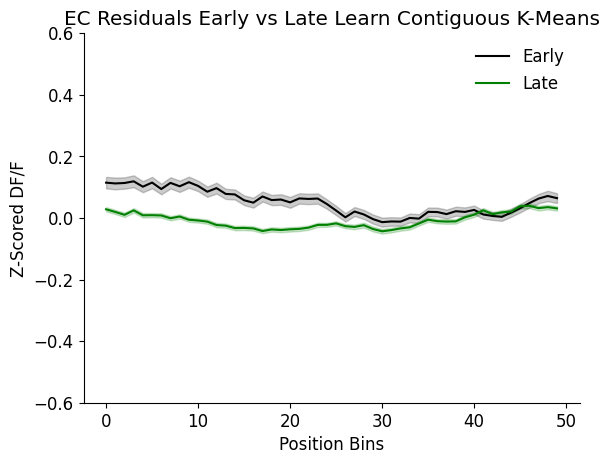

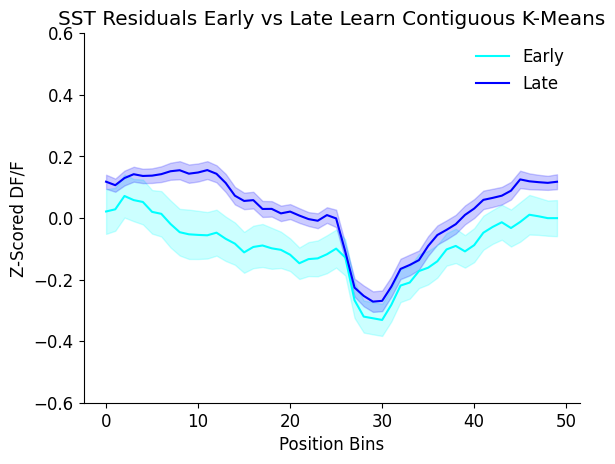

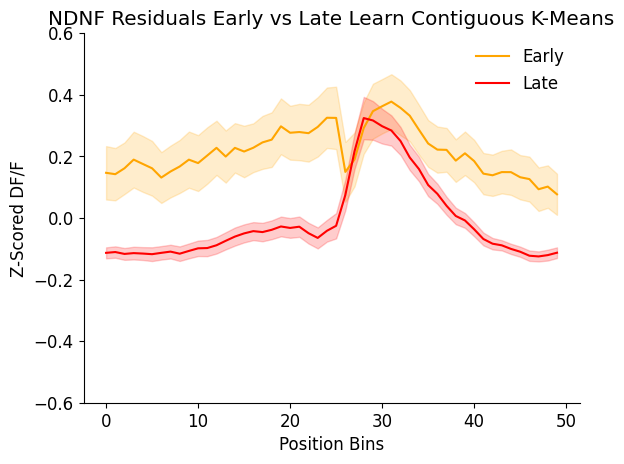

In [31]:

def plot_mean_fill(SST_data_array_early, SST_data_array_late, color_e='cyan', color_l='blue', title="SST Early vs Late Learn Cut By Contiguous K-Means"):

    mean_SST_data_array_early = np.mean(SST_data_array_early, axis=0)
    sem_SST_data_array_early = sem(SST_data_array_early, axis=0)
    mean_SST_data_array_late = np.mean(SST_data_array_late, axis=0)
    sem_SST_data_array_late = sem(SST_data_array_late, axis=0)

    plt.plot(mean_SST_data_array_early, color=color_e, label='Early')
    plt.fill_between(range(len(mean_SST_data_array_early)), mean_SST_data_array_early-sem_SST_data_array_early, mean_SST_data_array_early+sem_SST_data_array_early, alpha=0.2, color=color_e)
    plt.plot(mean_SST_data_array_late, color=color_l, label='Late')
    plt.fill_between(range(len(mean_SST_data_array_late)), mean_SST_data_array_late-sem_SST_data_array_late, mean_SST_data_array_late+sem_SST_data_array_late, alpha=0.2, color=color_l)
    plt.xlabel("Position Bins")
    plt.ylabel("Z-Scored DF/F")
    plt.title(title)
    plt.legend()
    plt.ylim(-0.6, 0.6)
    plt.show()


# plot_mean_fill(EC_data_array_early, EC_data_array_late, color_e='k', color_l='green', title="EC Raw Early vs Late Learn Contiguous K-Means")
# plot_mean_fill(SST_data_array_early, SST_data_array_late, color_e='cyan', color_l='blue', title="SST Raw Early vs Late Learn Contiguous K-Means")
# plot_mean_fill(NDNF_data_array_early, NDNF_data_array_late, color_e='orange', color_l='red', title="NDNF Raw Early vs Late Learn Contiguous K-Means")


plot_mean_fill(EC_data_array_early_r, EC_data_array_late_r, color_e='k', color_l='green', title="EC Residuals Early vs Late Learn Contiguous K-Means")
plot_mean_fill(SST_data_array_early_r, SST_data_array_late_r, color_e='cyan', color_l='blue', title="SST Residuals Early vs Late Learn Contiguous K-Means")
plot_mean_fill(NDNF_data_array_early_r, NDNF_data_array_late_r, color_e='orange', color_l='red', title="NDNF Residuals Early vs Late Learn Contiguous K-Means")


Help on function get_binned_data_for_CDF in module selectivity_over_learning_utils:

get_binned_data_for_CDF(animal_average_selectivity_dict_SST_r, n_bins=20)
    params animal_average_selectivity_dict_SST_r: selectivity value for every cell in a dict
    returns binned_data: the cells with selectiivty values that fit within each bin (percent of data)

Help on function get_selectivity_each_trial in module selectivity_over_learning_utils:

get_selectivity_each_trial(activity_dict_EC, neg_sel=True, trial_av=False)
    - get a selectivity for every trial of every cell and then average it to be the selectivity for that cell or trial_av will trial average first and then run the selectivity on that trial averaged trace  if the trial_av flag is False
    returns: animal_average_selectivity_dict - every cell gets a single value from either the selectivity of the trial averaged trace or the average of all selectivity metrics quantified for every trial individually



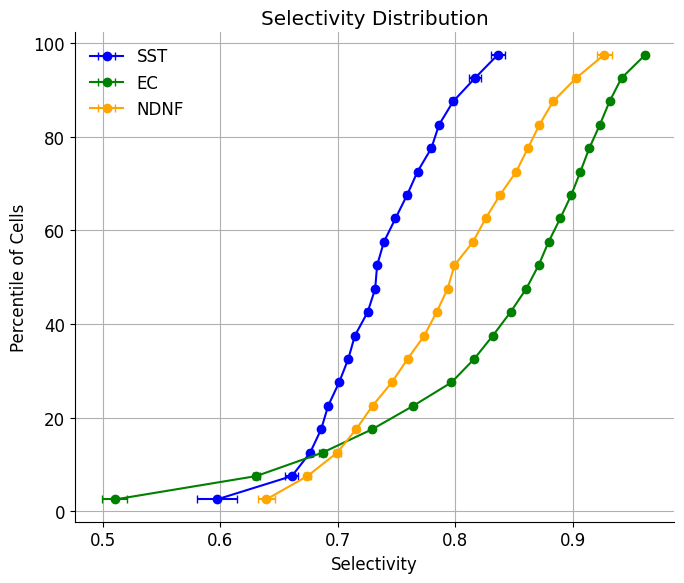

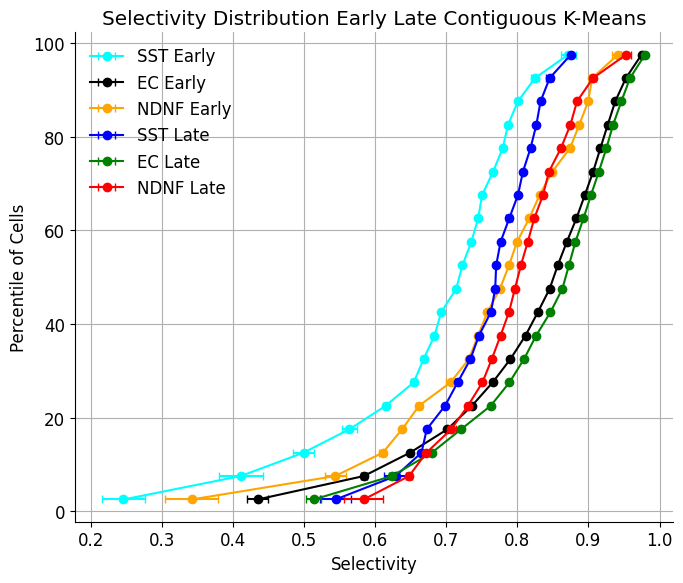

In [32]:


help(get_binned_data_for_CDF)
help(get_selectivity_each_trial)


animal_average_selectivity_dict_EC_r = get_selectivity_each_trial(residual_activity_dict_EC, neg_sel=False, trial_av=False)
animal_average_selectivity_dict_SST_r = get_selectivity_each_trial(residual_activity_dict_SST, neg_sel=False, trial_av=False)
animal_average_selectivity_dict_NDNF_r = get_selectivity_each_trial(fixed_activity_dict_NDNF_newest, neg_sel=False, trial_av=False)



binned_data_SST = get_binned_data_for_CDF(animal_average_selectivity_dict_SST_r, n_bins=20)
binned_data_EC = get_binned_data_for_CDF(animal_average_selectivity_dict_EC_r, n_bins=20)
binned_data_NDNF = get_binned_data_for_CDF(animal_average_selectivity_dict_NDNF_r, n_bins=20)

plot_the_CDF(binned_data_SST, binned_data_EC, binned_data_NDNF, title="Selectivity Distribution")


animal_average_selectivity_dict_EC_r_early = get_selectivity_each_trial_early_late(residual_activity_dict_EC, cp_dict_EC, neg_sel=True, trial_av=False, use_early=True)
animal_average_selectivity_dict_SST_r_early = get_selectivity_each_trial_early_late(residual_activity_dict_SST, cp_dict_SST, neg_sel=False, trial_av=False, use_early=True)
animal_average_selectivity_dict_NDNF_r_early = get_selectivity_each_trial_early_late(fixed_activity_dict_NDNF_newest, cp_dict_NDNF, neg_sel=False, trial_av=False, use_early=True)

animal_average_selectivity_dict_EC_r_late = get_selectivity_each_trial_early_late(residual_activity_dict_EC, cp_dict_EC, neg_sel=True, trial_av=False, use_early=False)
animal_average_selectivity_dict_SST_r_late = get_selectivity_each_trial_early_late(residual_activity_dict_SST, cp_dict_SST, neg_sel=False, trial_av=False, use_early=False)
animal_average_selectivity_dict_NDNF_r_late = get_selectivity_each_trial_early_late(fixed_activity_dict_NDNF_newest, cp_dict_NDNF, neg_sel=False, trial_av=False, use_early=False)

binned_data_SST_e = get_binned_data_for_CDF(animal_average_selectivity_dict_SST_r_early, n_bins=20)
binned_data_EC_e = get_binned_data_for_CDF(animal_average_selectivity_dict_EC_r_early, n_bins=20)
binned_data_NDNF_e = get_binned_data_for_CDF(animal_average_selectivity_dict_NDNF_r_early, n_bins=20)

binned_data_SST_l = get_binned_data_for_CDF(animal_average_selectivity_dict_SST_r_late, n_bins=20)
binned_data_EC_l = get_binned_data_for_CDF(animal_average_selectivity_dict_EC_r_late, n_bins=20)
binned_data_NDNF_l = get_binned_data_for_CDF(animal_average_selectivity_dict_NDNF_r_late, n_bins=20)

plot_the_CDF_early_late(binned_data_SST_e, binned_data_EC_e, binned_data_NDNF_e, binned_data_SST_l, binned_data_EC_l, binned_data_NDNF_l, title="Selectivity Distribution Early Late Contiguous K-Means")

Help on function get_binned_data_for_CDF in module selectivity_over_learning_utils:

get_binned_data_for_CDF(animal_average_selectivity_dict_SST_r, n_bins=20)
    params animal_average_selectivity_dict_SST_r: selectivity value for every cell in a dict
    returns binned_data: the cells with selectiivty values that fit within each bin (percent of data)

Help on function get_selectivity_each_trial in module selectivity_over_learning_utils:

get_selectivity_each_trial(activity_dict_EC, neg_sel=True, trial_av=False)
    - get a selectivity for every trial of every cell and then average it to be the selectivity for that cell or trial_av will trial average first and then run the selectivity on that trial averaged trace  if the trial_av flag is False
    returns: animal_average_selectivity_dict - every cell gets a single value from either the selectivity of the trial averaged trace or the average of all selectivity metrics quantified for every trial individually



/Users/michaelfinch/miniconda3/envs/ca1_env/lib/python3.11/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/michaelfinch/miniconda3/envs/ca1_env/lib/python3.11/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/Users/michaelfinch/CA1-interneuron-GLM/Clean_notebooks_to_date/selectivity_over_learning_utils.py:139: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  sem_data_list.append(sem(bin_data))


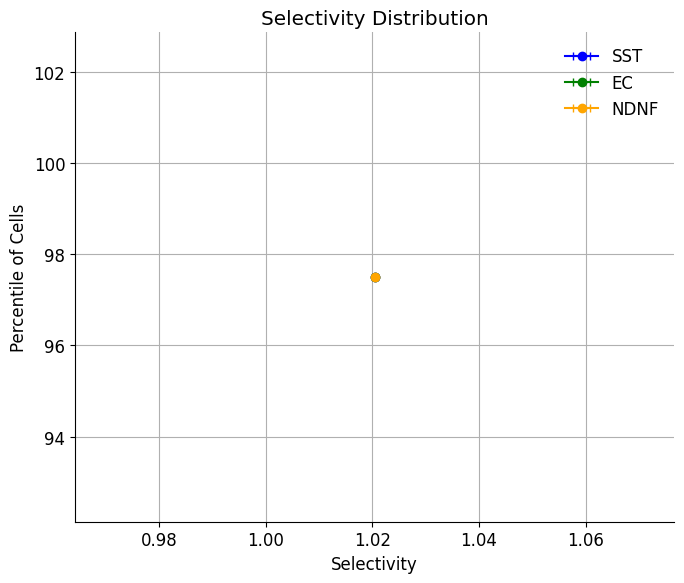

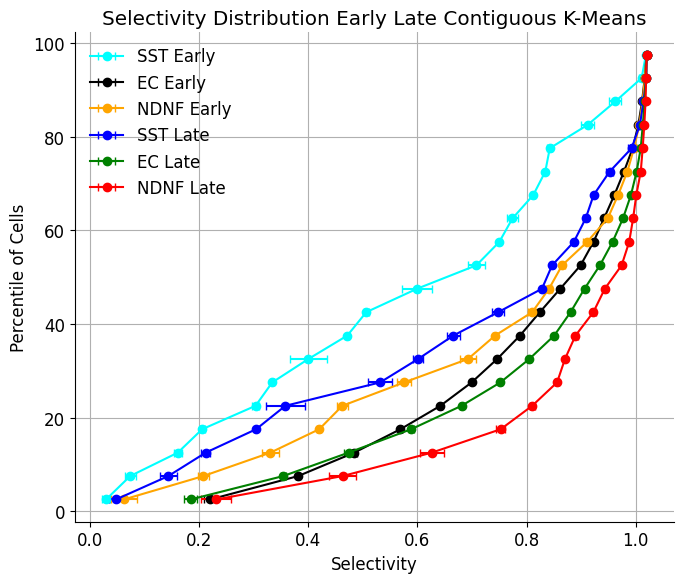

In [33]:


help(get_binned_data_for_CDF)
help(get_selectivity_each_trial)


ta=True

animal_average_selectivity_dict_EC_r = get_selectivity_each_trial(residual_activity_dict_EC, neg_sel=False, trial_av=ta)
animal_average_selectivity_dict_SST_r = get_selectivity_each_trial(residual_activity_dict_SST, neg_sel=False, trial_av=ta)
animal_average_selectivity_dict_NDNF_r = get_selectivity_each_trial(fixed_activity_dict_NDNF_newest, neg_sel=False, trial_av=ta)



binned_data_SST = get_binned_data_for_CDF(animal_average_selectivity_dict_SST_r, n_bins=20)
binned_data_EC = get_binned_data_for_CDF(animal_average_selectivity_dict_EC_r, n_bins=20)
binned_data_NDNF = get_binned_data_for_CDF(animal_average_selectivity_dict_NDNF_r, n_bins=20)

plot_the_CDF(binned_data_SST, binned_data_EC, binned_data_NDNF, title="Selectivity Distribution")


animal_average_selectivity_dict_EC_r_early = get_selectivity_each_trial_early_late(residual_activity_dict_EC, cp_dict_EC, neg_sel=True, trial_av=ta, use_early=True)
animal_average_selectivity_dict_SST_r_early = get_selectivity_each_trial_early_late(residual_activity_dict_SST, cp_dict_SST, neg_sel=False, trial_av=ta, use_early=True)
animal_average_selectivity_dict_NDNF_r_early = get_selectivity_each_trial_early_late(fixed_activity_dict_NDNF_newest, cp_dict_NDNF, neg_sel=False, trial_av=ta, use_early=True)

animal_average_selectivity_dict_EC_r_late = get_selectivity_each_trial_early_late(residual_activity_dict_EC, cp_dict_EC, neg_sel=True, trial_av=ta, use_early=False)
animal_average_selectivity_dict_SST_r_late = get_selectivity_each_trial_early_late(residual_activity_dict_SST, cp_dict_SST, neg_sel=False, trial_av=ta, use_early=False)
animal_average_selectivity_dict_NDNF_r_late = get_selectivity_each_trial_early_late(fixed_activity_dict_NDNF_newest, cp_dict_NDNF, neg_sel=False, trial_av=ta, use_early=False)

binned_data_SST_e = get_binned_data_for_CDF(animal_average_selectivity_dict_SST_r_early, n_bins=20)
binned_data_EC_e = get_binned_data_for_CDF(animal_average_selectivity_dict_EC_r_early, n_bins=20)
binned_data_NDNF_e = get_binned_data_for_CDF(animal_average_selectivity_dict_NDNF_r_early, n_bins=20)

binned_data_SST_l = get_binned_data_for_CDF(animal_average_selectivity_dict_SST_r_late, n_bins=20)
binned_data_EC_l = get_binned_data_for_CDF(animal_average_selectivity_dict_EC_r_late, n_bins=20)
binned_data_NDNF_l = get_binned_data_for_CDF(animal_average_selectivity_dict_NDNF_r_late, n_bins=20)

plot_the_CDF_early_late(binned_data_SST_e, binned_data_EC_e, binned_data_NDNF_e, binned_data_SST_l, binned_data_EC_l, binned_data_NDNF_l, title="Selectivity Distribution Early Late Contiguous K-Means")

In [34]:
setup_CDF_plotting_for_selectivity(activity_dict_SST, predicted_activity_dict_SST, activity_dict_NDNF, predicted_activity_dict_NDNF, activity_dict_EC, predicted_activity_dict_EC, residual=False)

NameError: name 'predicted_activity_dict_SST' is not defined

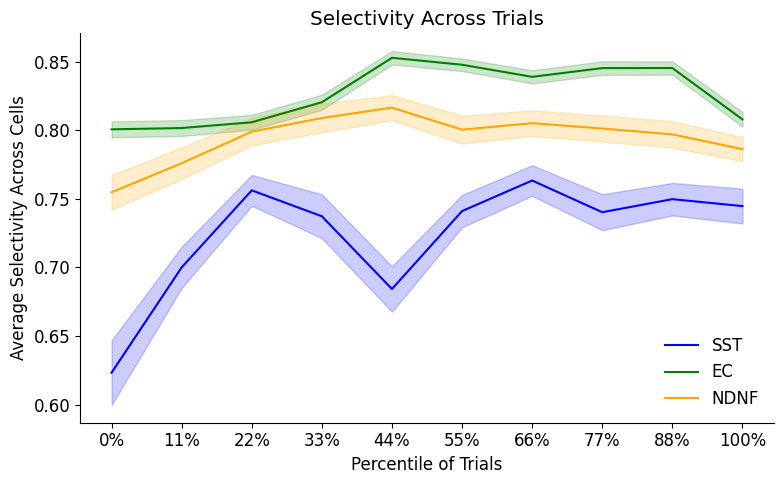

In [ ]:

################# plotting selectivity by percentile of trials --- didnt work 



# def Vinje2000(tuning_curve, norm='None', negative_selectivity=False):
    # if norm == 'min_max':
    #     tuning_curve = (tuning_curve - np.min(tuning_curve)) / (np.max(tuning_curve) - np.min(tuning_curve))
    #     if negative_selectivity:
    #         tuning_curve = np.absolute(1 - tuning_curve)
    # elif norm == 'z_score':
    #     tuning_curve = (tuning_curve - np.mean(tuning_curve)) / np.std(tuning_curve)
    #     if negative_selectivity:
    #         tuning_curve = np.absolute(1 - tuning_curve)
    # A = np.mean(tuning_curve) ** 2 / np.mean(tuning_curve ** 2)
    # return (1 - A) / (1 - 1 / len(tuning_curve))


# def get_selectivity_for_plotting(activity_dict_SST, predicted_activity_dict_SST, residual=False):

taa=False

percentile_slices_SST = get_percentlie_slices(activity_dict_SST)
percentile_slices_NDNF = get_percentlie_slices(fixed_activity_dict_NDNF_newest)
percentile_slices_EC = get_percentlie_slices(activity_dict_EC)

percentile_slices_SST_r = get_percentlie_slices(residual_activity_dict_SST)
percentile_slices_NDNF_r = get_percentlie_slices(fixed_residual_activity_dict_NDNF_newest)
percentile_slices_EC_r = get_percentlie_slices(residual_activity_dict_EC)


animal_average_selectivity_dict_SST = get_animal_average_selectivity_dict(percentile_slices_SST, neg_sel=False, trial_av=taa)
animal_average_selectivity_dict_EC = get_animal_average_selectivity_dict(percentile_slices_EC, neg_sel=False, trial_av=taa)
animal_average_selectivity_dict_NDNF = get_animal_average_selectivity_dict(percentile_slices_NDNF, neg_sel=False, trial_av=taa)


animal_average_selectivity_dict_SST_r = get_animal_average_selectivity_dict(percentile_slices_SST_r, neg_sel=False, trial_av=taa)
animal_average_selectivity_dict_EC_r = get_animal_average_selectivity_dict(percentile_slices_EC_r, neg_sel=False, trial_av=taa)
animal_average_selectivity_dict_NDNF_r = get_animal_average_selectivity_dict(percentile_slices_NDNF_r, neg_sel=False, trial_av=taa)

all_cell_selectivity_SST = get_selectivity_array(animal_average_selectivity_dict_SST)
all_cell_selectivity_EC = get_selectivity_array(animal_average_selectivity_dict_EC)
all_cell_selectivity_NDNF = get_selectivity_array(animal_average_selectivity_dict_NDNF)

# Step 3: compute mean and SEM across cells




plot_selectivity_over_trials(all_cell_selectivity_SST, all_cell_selectivity_EC, all_cell_selectivity_NDNF)


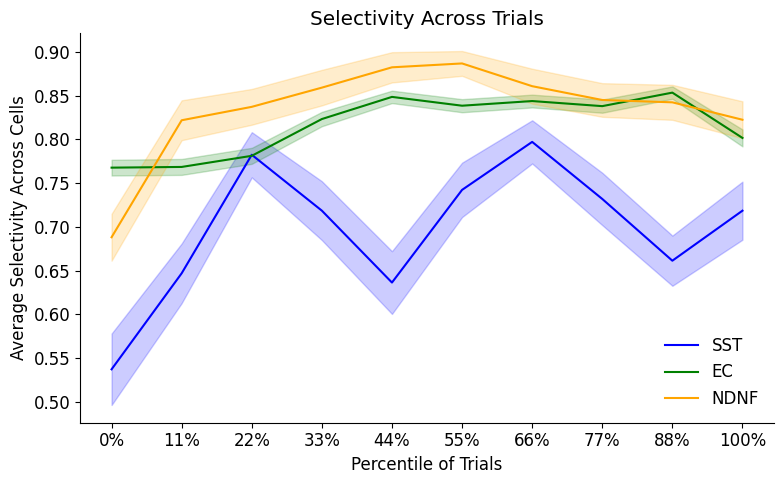

In [ ]:

################# plotting selectivity by percentile of trials --- didnt work 



# def Vinje2000(tuning_curve, norm='None', negative_selectivity=False):
    # if norm == 'min_max':
    #     tuning_curve = (tuning_curve - np.min(tuning_curve)) / (np.max(tuning_curve) - np.min(tuning_curve))
    #     if negative_selectivity:
    #         tuning_curve = np.absolute(1 - tuning_curve)
    # elif norm == 'z_score':
    #     tuning_curve = (tuning_curve - np.mean(tuning_curve)) / np.std(tuning_curve)
    #     if negative_selectivity:
    #         tuning_curve = np.absolute(1 - tuning_curve)
    # A = np.mean(tuning_curve) ** 2 / np.mean(tuning_curve ** 2)
    # return (1 - A) / (1 - 1 / len(tuning_curve))


# def get_selectivity_for_plotting(activity_dict_SST, predicted_activity_dict_SST, residual=False):

taa=True

percentile_slices_SST = get_percentlie_slices(activity_dict_SST)
percentile_slices_NDNF = get_percentlie_slices(fixed_activity_dict_NDNF_newest)
percentile_slices_EC = get_percentlie_slices(activity_dict_EC)

percentile_slices_SST_r = get_percentlie_slices(residual_activity_dict_SST)
percentile_slices_NDNF_r = get_percentlie_slices(fixed_residual_activity_dict_NDNF_newest)
percentile_slices_EC_r = get_percentlie_slices(residual_activity_dict_EC)


animal_average_selectivity_dict_SST = get_animal_average_selectivity_dict(percentile_slices_SST, neg_sel=False, trial_av=taa)
animal_average_selectivity_dict_EC = get_animal_average_selectivity_dict(percentile_slices_EC, neg_sel=False, trial_av=taa)
animal_average_selectivity_dict_NDNF = get_animal_average_selectivity_dict(percentile_slices_NDNF, neg_sel=False, trial_av=taa)


animal_average_selectivity_dict_SST_r = get_animal_average_selectivity_dict(percentile_slices_SST_r, neg_sel=False, trial_av=taa)
animal_average_selectivity_dict_EC_r = get_animal_average_selectivity_dict(percentile_slices_EC_r, neg_sel=False, trial_av=taa)
animal_average_selectivity_dict_NDNF_r = get_animal_average_selectivity_dict(percentile_slices_NDNF_r, neg_sel=False, trial_av=taa)

all_cell_selectivity_SST = get_selectivity_array(animal_average_selectivity_dict_SST)
all_cell_selectivity_EC = get_selectivity_array(animal_average_selectivity_dict_EC)
all_cell_selectivity_NDNF = get_selectivity_array(animal_average_selectivity_dict_NDNF)

# Step 3: compute mean and SEM across cells




plot_selectivity_over_trials(all_cell_selectivity_SST, all_cell_selectivity_EC, all_cell_selectivity_NDNF)


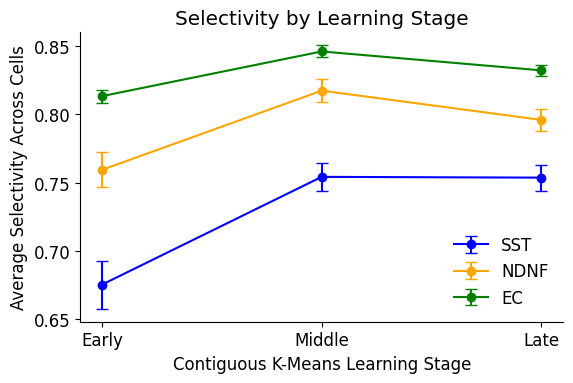

In [ ]:
########### split by learning chunk 

tas=False

animal_average_selectivity_dict_SST = get_animal_average_selectivity_dict_eml(residual_activity_dict_SST, cp_dict_SST, neg_sel=True, trial_av=tas)
animal_average_selectivity_dict_EC = get_animal_average_selectivity_dict_eml(residual_activity_dict_EC, cp_dict_EC, neg_sel=True, trial_av=tas)
animal_average_selectivity_dict_NDNF = get_animal_average_selectivity_dict_eml(fixed_residual_activity_dict_NDNF_newest, cp_dict_NDNF, neg_sel=True, trial_av=tas)

plot_selectivity_seperated_by_learn_stage(animal_average_selectivity_dict_SST, animal_average_selectivity_dict_NDNF, animal_average_selectivity_dict_EC)


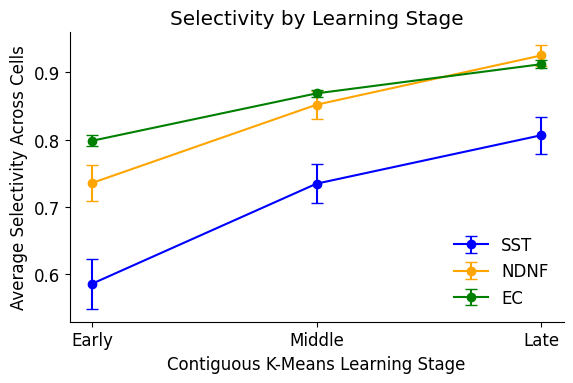

In [ ]:
########### split by learning chunk 

tas=True

animal_average_selectivity_dict_SST = get_animal_average_selectivity_dict_eml(residual_activity_dict_SST, cp_dict_SST, neg_sel=True, trial_av=tas)
animal_average_selectivity_dict_EC = get_animal_average_selectivity_dict_eml(residual_activity_dict_EC, cp_dict_EC, neg_sel=True, trial_av=tas)
animal_average_selectivity_dict_NDNF = get_animal_average_selectivity_dict_eml(fixed_residual_activity_dict_NDNF_newest, cp_dict_NDNF, neg_sel=True, trial_av=tas)

plot_selectivity_seperated_by_learn_stage(animal_average_selectivity_dict_SST, animal_average_selectivity_dict_NDNF, animal_average_selectivity_dict_EC)
